In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')
import seaborn as sns
import matplotlib.pyplot as plt

/kaggle/input/datasets/mojtaba142/hotel-booking/hotel_booking.csv


In [2]:
df = pd.read_csv('/kaggle/input/datasets/mojtaba142/hotel-booking/hotel_booking.csv')

# Data Inspection

In [3]:
# General inspection of the dataset
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498


In [4]:
# Statistic Metrics of the dataset
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [5]:
# Checking the shape of the dataset
print(f'Rows:{df.shape[0]} -- Columns: {df.shape[1]}')

Rows:119390 -- Columns: 36


In [6]:
# Check missing values
df.isna().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [7]:
# Check for duplicates
df.duplicated().sum()

df[df.duplicated()]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card


**Note:** The dataset used in this project is an extended version of the original Hotel Booking Demand dataset. Additional synthetic customer-identification fields (name, email, phone number, credit card) eliminate the duplicate records commonly reported in the original dataset.

# Explorative Data Analysis

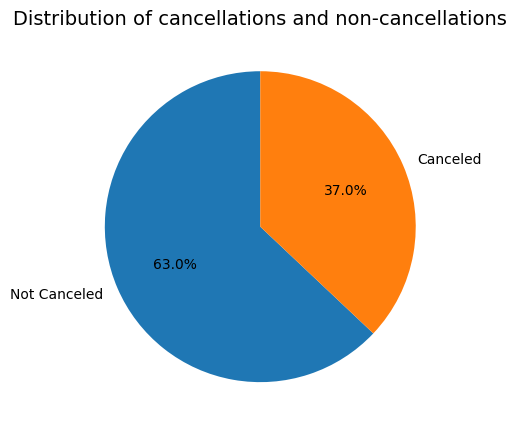

In [8]:
# Question: What is the breakdown of cancellations and non-cancellations
# Visualize the distribution of cancellation and non-cancellation
cancellation_counts = df['is_canceled'].value_counts()
plt.figure(figsize=(5,5))
plt.pie(cancellation_counts, labels=['Not Canceled', 'Canceled'], autopct='%1.1f%%', startangle=90)

plt.title('Distribution of cancellations and non-cancellations', fontsize=14)
plt.tight_layout()
plt.show()

### Analysis: Breakdown of Cancellations
The chart reveals that while **63.0%** of the bookings are successfully completed (not canceled), a substantial **37.0%** of all bookings end up being canceled. 

In the hospitality industry, a cancellation rate this high severely impacts revenue stability and room capacity planning. This finding strongly demands further investigations to identify the driving factors behind these cancellations (e.g., specific customer types, deposit policies, or lead times).

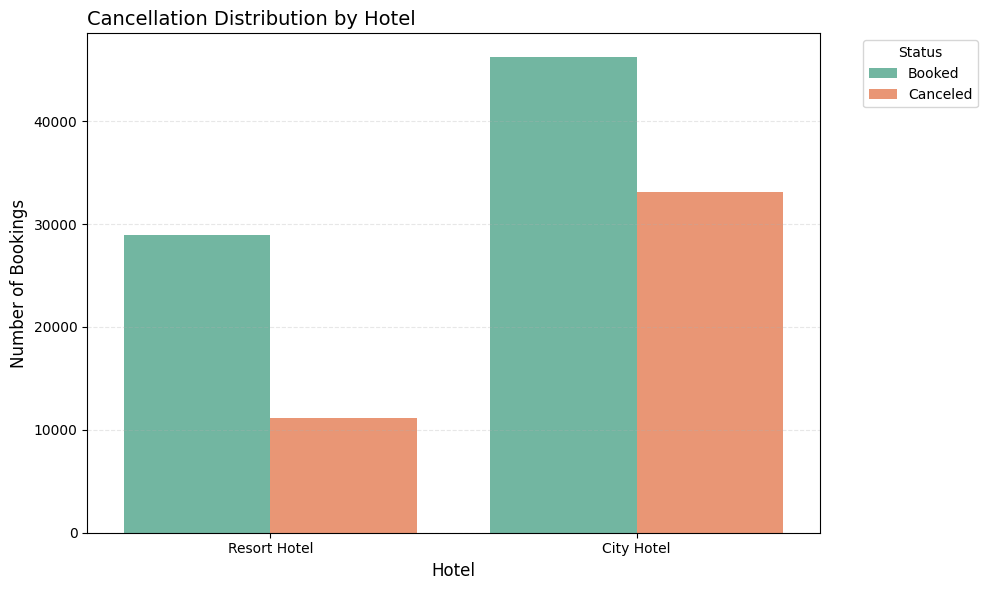

--Realtiv Cancellation Rate---
City Hotel: 41.73%
Resort Hotel: 27.76%


In [9]:
# Questions: Does the City Hotel or Resort Hotel has more cancellations? 
hotel_df = df.groupby('hotel')['is_canceled'].value_counts()

plt.figure(figsize=(10,6))
sns.countplot(data=df, x='hotel', hue='is_canceled', palette='Set2')
plt.title('Cancellation Distribution by Hotel', fontsize=14, loc='left')
plt.xlabel('Hotel', fontsize=12)
plt.ylabel('Number of Bookings', fontsize=12)
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left', title='Status', labels=['Booked', 'Canceled'])
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


print('--Realtiv Cancellation Rate---')
city_hotel = round(33102 / (46228 + 33102) * 100, 2)
resort_hotel = round(11122 / (28938 + 11122) * 100, 2)
print(f'City Hotel: {city_hotel}%')
print(f'Resort Hotel: {resort_hotel}%')

### Analysis of Cancellation Distribution by Hotel
* **City Hotel:** The chart illustrates that the City Hotel experiences a significantly higher volume of cancellations in absolute numbers. When looking at the ratio, the cancellation rate reaches roughly **41.73%** (approx. 33,000 cancellations out of 79,000 total bookings). This is exceptionally high and requires a deep-dive evaluation into the underlying reasons.
* **Resort Hotel:** In contrast, the Resort Hotel shows a healthier balance between confirmed and canceled bookings. With a cancellation rate of about **27.76%** (approx. 11,000 cancellations out of 40,000 total bookings), it proves to be more stable, which is typical for leisure travel where trips are planned further in advance and less likely to be dropped.

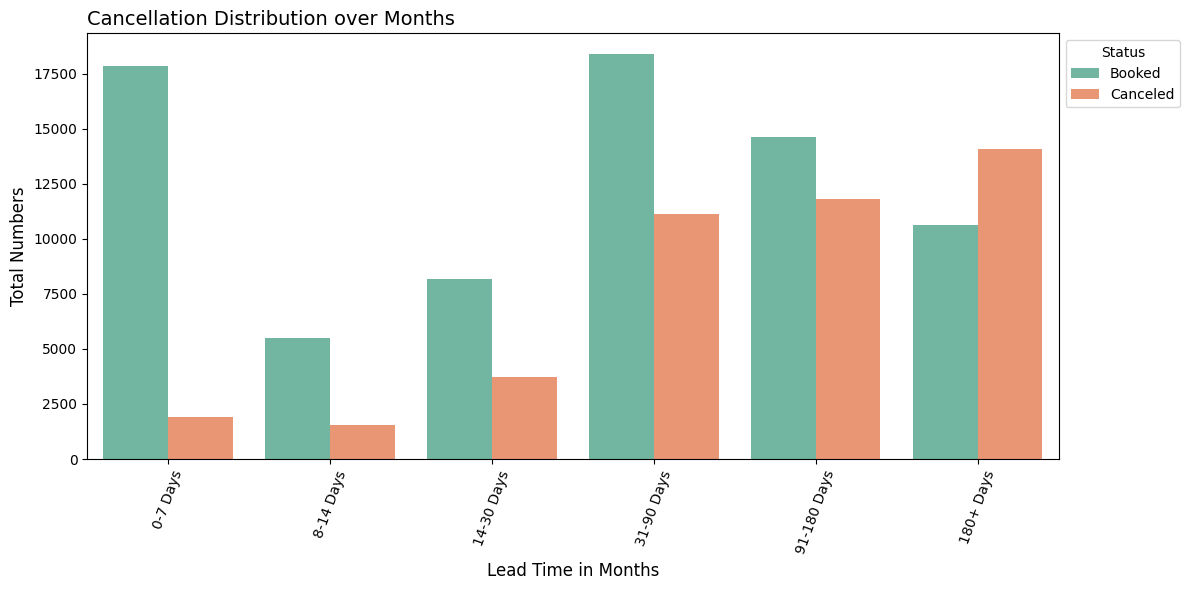

In [10]:
# Question: Is there a context between lead time and cancellation
# Analys with pd.cut to group the lead time days into months for better overview
month_bins = [-1, 7, 14, 30, 90, 180, float('inf')]
month_labels = ['0-7 Days', '8-14 Days', '14-30 Days', '31-90 Days', '91-180 Days', '180+ Days']

df['lead_time_group'] = pd.cut(df['lead_time'], bins=month_bins, labels=month_labels)

plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='lead_time_group', hue='is_canceled', palette='Set2')
plt.title('Cancellation Distribution over Months', fontsize=14, loc='left')
plt.xlabel('Lead Time in Months', fontsize=12)
plt.ylabel('Total Numbers', fontsize=12)
plt.legend(bbox_to_anchor=(1,1), loc='upper left', title='Status', labels=['Booked', 'Canceled'])
plt.xticks(rotation=70)

plt.tight_layout()
plt.show()

### Analysis: Lead Time vs. Cancellations
* **Observation:** The chart clearly reveals that the majority of cancellations occur between 3 and 6 months prior to arrival. In contrast, bookings made 14 days to 1 month before arrival show very low cancellation rates. This indicates a high volatility in guest commitment during the 3-to-6-month window.
* **Business Recommendation:** To maximize occupancy and revenue, the hotel management should implement a strategic **overbooking policy** specifically targeting reservations made 3 to 6 months in advance. By factoring in this predictable cancellation wave, the hotel can ensure it remains closer to 100% capacity when the actual arrival date approaches.

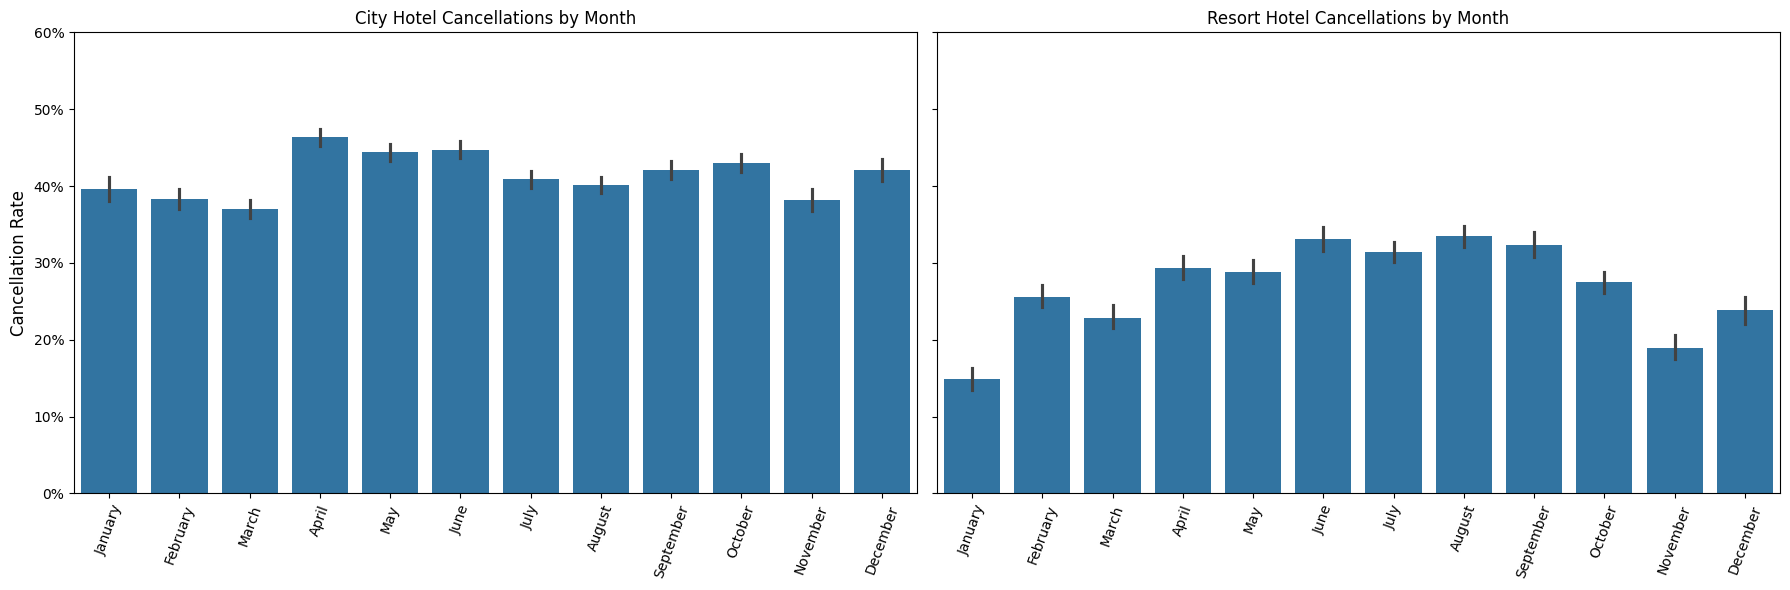

In [11]:
# Setting a months order instead of a-z
months = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
city_hotel_df = df[df['hotel'] == 'City Hotel']
resort_hotel_df =df[df['hotel'] == 'Resort Hotel']

fig, axes = plt.subplots(1, 2, figsize=(18,6), sharey=True)
sns.barplot(data=city_hotel_df, x='arrival_date_month', y='is_canceled', order=months, ax=axes[0])
axes[0].set_xlabel('')
axes[0].set_title('City Hotel Cancellations by Month', fontsize=12)
axes[0].tick_params(axis='x', rotation=70)

axes[0].set_ylabel('Cancellation Rate', fontsize=12)
axes[0].set_ylim(0.0, 0.6)
axes[0].set_yticks([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6])
axes[0].set_yticklabels(['0%', '10%', '20%', '30%', '40%', '50%', '60%'])

sns.barplot(data=resort_hotel_df, x='arrival_date_month', y='is_canceled', order=months, ax=axes[1])
axes[1].set_xlabel('')
axes[1].set_title('Resort Hotel Cancellations by Month', fontsize=12)
axes[1].tick_params(axis='x', rotation=70)

plt.tight_layout()
plt.show()


### Analysis: Cancellation Distribution by Month & Hotel
* **City Hotel (Structural Risk):** The chart reveals an alarming trend for the City Hotel, where the cancellation rate hovers consistently around **40% almost every single month**, regardless of the season. This indicates a deep structural issue—likely driven by business travelers or short-notice online bookings. Immediate operational actions, such as introducing non-refundable base rates or mandatory credit card pre-authorization, are required.
* **Resort Hotel (Seasonal Risk):** In contrast, the Resort Hotel shows a much healthier, classic seasonal distribution. Cancellations peak significantly during the **summer months (June, July, August, September), reaching up to 30%**. This reflects the volatile nature of holiday bookings, which are planned long in advance. 
* **Strategic Recommendation:** While the City Hotel needs a year-round, strict cancellation policy, the Resort Hotel should implement **dynamic seasonal restrictions**. For instance, during the high-season summer months, the hotel should enforce stricter deposit requirements (e.g., a 20% non-refundable deposit) to secure revenue against late cancellations.

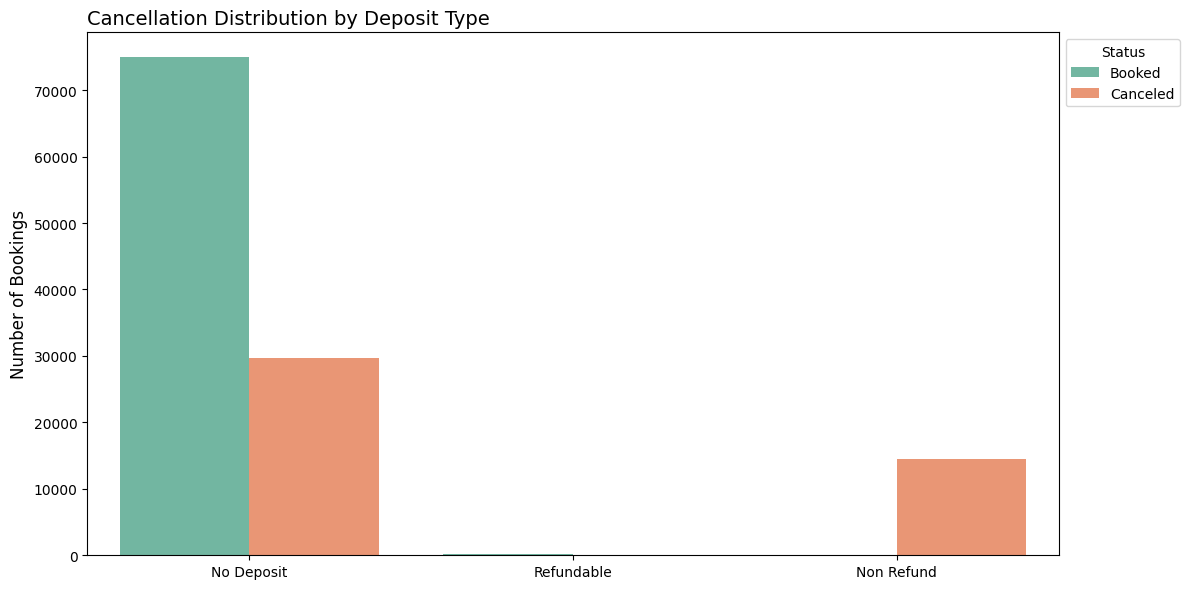

In [12]:
# Visualize the deposit type and cancellation distribution
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='deposit_type', hue='is_canceled', palette='Set2')
plt.title('Cancellation Distribution by Deposit Type', fontsize=14, loc='left')
plt.xlabel('')
plt.ylabel('Number of Bookings', fontsize=12)
plt.legend(bbox_to_anchor=(1,1), loc='upper left', title='Status', labels=['Booked', 'Canceled'])

plt.tight_layout()
plt.show()

### Analysis : Cancellation Distribution by Deposit Type
* **The Non-Refundable Paradox:** The chart reveals a massive, counter-intuitive anomaly: bookings with a **"Non Refund" policy have a cancellation rate of nearly 99%** (where `is_canceled = 1`). Intuitively, guests paying upfront without a refund option should be the least likely to cancel. This indicates a systemic issue—potentially driven by large travel agency group bookings (wholesalers blocking and dropping contingencies) or credit card fraud/chargeback patterns.
* **The Irrelevance of Refundable Rates:** "Refundable" deposits are practically non-existent in the dataset. Since this rate type generates neither significant bookings nor predictable revenue, hotel management should consider **deactivating this option entirely** to simplify the tariff structure and streamline distribution channels.
* **Main Business Volume:** The vast majority of bookings are made under the **"No Deposit"** policy. This is the hotel's main volume driver, showing a standard, expected cancellation split.

* **Strategic Recommendation:** 
  1. **Audit Distribution Channels:** Management must immediately audit which specific booking platforms or market segments the "Non Refund" bookings originate from. 
  2. **Fraud Prevention:** Implement stricter automated credit card pre-authorization and fraud checks at the time of booking to reduce malicious or volatile automated bookings.
  3. **Financial Investigation:** Further investigate if the "Non-Refundable" fees were actually collected by accounting or if these represent unrecovered revenue losses (e.g., due to successful chargebacks).